In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import os, random
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_all_seeds(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
START_DATE = "2020-06-08"

def load_era5(files):
    return xr.open_mfdataset(files, combine="by_coords").sortby("valid_time")

era5_files = [
    "/content/drive/MyDrive/mtp2/era5_inputs/era5_india_2020_06.nc",
    "/content/drive/MyDrive/mtp2/era5_inputs/era5_india_2020_07.nc",
    "/content/drive/MyDrive/mtp2/era5_inputs/era5_india_2020_08.nc",
    "/content/drive/MyDrive/mtp2/era5_inputs/era5_india_2020_09.nc",
]

era5_ds = load_era5(era5_files)
era5_ds = era5_ds.sel(valid_time=slice(START_DATE, None))

def load_era5_rain(files):
    ds = xr.open_mfdataset(files, combine="by_coords").sortby("valid_time")
    ds["tp"] = ds["tp"] * 1000.0
    return ds[["tp"]]

era5_rain_files = [
    "/content/drive/MyDrive/mtp2/era5_rain/era5_rain_2020_06.nc",
    "/content/drive/MyDrive/mtp2/era5_rain/era5_rain_2020_07.nc",
    "/content/drive/MyDrive/mtp2/era5_rain/era5_rain_2020_08.nc",
    "/content/drive/MyDrive/mtp2/era5_rain/era5_rain_2020_09.nc",
]

era5_rain_ds = load_era5_rain(era5_rain_files)
era5_rain_ds = era5_rain_ds.sel(valid_time=slice(START_DATE, None))

lat = era5_rain_ds.latitude.values
lon = era5_rain_ds.longitude.values

lon2d, lat2d = np.meshgrid(lon, lat)

imdaa_raw = xr.open_mfdataset(
    "/content/drive/MyDrive/mtp2/imdaa_rain/rainfall_india_2020_*.nc",
    combine="by_coords"
).sortby("time")

rf3h = imdaa_raw["rf"].load()
imdaa_raw.close()

In [ ]:
def build_samples(era5_ds, era5_rain, rf3h):
    pairs = []
    era5_times = pd.to_datetime(era5_ds.valid_time.values)
    rain_times = pd.to_datetime(era5_rain.valid_time.values)
    imdaa_times = pd.to_datetime(rf3h.time.values)

    for t in era5_times:
        t3 = t + pd.Timedelta(hours=3)
        t6 = t + pd.Timedelta(hours=6)

        if (t6 in rain_times) and (t3 in imdaa_times) and (t6 in imdaa_times):
            pairs.append((t, t3, t6))
    return pairs

samples = build_samples(era5_ds, era5_rain_ds, rf3h)
print("Valid samples:", len(samples))
print("First sample:", samples[0])

Valid samples: 427
First sample: (Timestamp('2020-06-08 00:00:00'), Timestamp('2020-06-08 03:00:00'), Timestamp('2020-06-08 06:00:00'))


In [ ]:
# Conv / Residual blocks
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, norm="group", groups=8):
        super().__init__()
        self.c1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.c2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        if norm == "batch":
            self.n1 = nn.BatchNorm2d(c_out); self.n2 = nn.BatchNorm2d(c_out)
        else:
            self.n1 = nn.GroupNorm(groups, c_out); self.n2 = nn.GroupNorm(groups, c_out)
        self.act = nn.GELU()
    def forward(self, x):
        x = self.act(self.n1(self.c1(x)))
        x = self.act(self.n2(self.c2(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, c, norm="group", groups=8):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, padding=1)
        self.conv2 = nn.Conv2d(c, c, 3, padding=1)
        if norm == "batch":
            self.n1 = nn.BatchNorm2d(c); self.n2 = nn.BatchNorm2d(c)
        else:
            self.n1 = nn.GroupNorm(groups, c); self.n2 = nn.GroupNorm(groups, c)
        self.act = nn.GELU()
    def forward(self, x):
        r = x
        x = self.act(self.n1(self.conv1(x)))
        x = self.n2(self.conv2(x))
        return self.act(x + r)

# U-Net
class UNetSmall(nn.Module):
    def __init__(self, in_ch, out_ch, base=64, norm="group", groups=8):
        super().__init__()
        self.down1 = ConvBlock(in_ch, base, norm, groups)
        self.down2 = ConvBlock(base, base*2, norm, groups)
        self.down3 = ConvBlock(base*2, base*4, norm, groups)
        self.pool = nn.AvgPool2d(2)
        self.mid = ResidualBlock(base*4, norm, groups)
        self.up3 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec3 = ConvBlock(base*4, base*2, norm, groups)
        self.up2 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec2 = ConvBlock(base*2, base, norm, groups)
        self.head = nn.Conv2d(base, out_ch, 1)
    def forward(self, x):
        _, _, H, W = x.shape
        e1 = self.down1(x)
        e2 = self.down2(self.pool(e1))
        e3 = self.down3(self.pool(e2))
        m = self.mid(e3)
        d3 = self.up3(m)
        if d3.shape[2:] != e2.shape[2:]:
            e2 = F.interpolate(e2, size=d3.shape[2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e2], dim=1))
        d2 = self.up2(d3)
        if d2.shape[2:] != e1.shape[2:]:
            e1 = F.interpolate(e1, size=d2.shape[2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))
        out = self.head(d2)
        if out.shape[2:] != (H, W):
            out = F.interpolate(out, size=(H, W), mode="bilinear", align_corners=False)
        return out

student = UNetSmall(in_ch=14, out_ch=14, base=64, norm="group", groups=8)

ckpt = torch.load(
    "/content/drive/MyDrive/mtp2/best_climate_model.pth",
    map_location=DEVICE,
    weights_only=False
)

student.load_state_dict(ckpt["model_state_dict"])
student.to(DEVICE).eval()

x_mean = ckpt["x_mean"].squeeze()
x_std  = ckpt["x_std"].squeeze()
y_mean = ckpt["y_mean"].squeeze()
y_std  = ckpt["y_std"].squeeze()

In [ ]:
def era5_to_tensor(ds, t):
    arr = [
        ds["t2m"].sel(valid_time=t), # (H,W)
        ds["u10"].sel(valid_time=t),
        ds["v10"].sel(valid_time=t),
        ds["msl"].sel(valid_time=t),
    ]
    for v in ["u", "v", "z", "t", "q"]:
        arr.append(ds[v].sel(valid_time=t, pressure_level=500))
        arr.append(ds[v].sel(valid_time=t, pressure_level=850))

    x = np.stack([a.values for a in arr], axis=0) # (14, H, W)
    x = (x - x_mean[:, None, None]) / x_std[:, None, None] # Normalize
    return torch.tensor(x, dtype=torch.float32) # (14, H, W)

def regrid_to_era5(imdaa, era5):
    return imdaa.interp(
        lat=era5.latitude,
        lon=era5.longitude,
        method="linear"
    )

In [ ]:
X_all = []
y_all = []
times_all = []

rf_era5_all = []
rf_imdaa_all = []

eps = 1e-3
rain_thresh = 1.0  # mm

with torch.no_grad():
    for t, t3, t6 in tqdm(samples):

        x = era5_to_tensor(era5_ds, t).unsqueeze(0).to(DEVICE) # 14 atms @ t
        pred = student(x)[0].cpu().numpy() # student forecasts to t+6
        pred = pred * y_std[:, None, None] + y_mean[:, None, None]

        t2m, u10, v10, msl = pred[0:4]
        u500, u850 = pred[4], pred[5]
        v500, v850 = pred[6], pred[7]
        z500, z850 = pred[8], pred[9]
        t500, t850 = pred[10], pred[11]
        q500, q850 = pred[12], pred[13]

        rf_era5 = era5_rain_ds["tp"].sel(valid_time=t6).values # era5 rf @ t+6

        rf_imdaa = (
            rf3h.sel(time=t3) +
            rf3h.sel(time=t6)
        ) # imdaa rf @ t+6

        rf_imdaa = regrid_to_era5(
            rf_imdaa,
            era5_rain_ds["tp"].sel(valid_time=t6)
        ).values # regrid to era5 grid

        if not np.isfinite(rf_imdaa).any():
            continue

        log_imdaa = np.log1p(rf_imdaa)
        log_era5  = np.log1p(rf_era5)
        rf_era5_log = np.log1p(rf_era5)

        bias_field = log_imdaa - log_era5 # Bias = log(1+IMDAA)−log(1+ERA5)
        bias_field = np.nan_to_num(bias_field, nan=0.0)

        rain_mask = (rf_imdaa > rain_thresh).astype(np.float32) # if imdaa rf > 1mm then 1 else 0

        feats = np.stack([
            t2m, u10, v10, msl,
            u500, u850, v500, v850,
            z500, z850, t500, t850,
            q500, q850,
            rf_era5_log,
            np.sin(np.deg2rad(lat2d)),
            np.cos(np.deg2rad(lat2d)),
            np.sin(np.deg2rad(lon2d)),
            np.cos(np.deg2rad(lon2d)),
        ], axis=0)

        feats = np.nan_to_num(feats, nan=0.0)

        X_all.append(feats)
        y_all.append(np.stack([bias_field, rain_mask], axis=0))
        rf_era5_all.append(rf_era5)
        rf_imdaa_all.append(rf_imdaa)
        times_all.append(t6)

X = np.stack(X_all)
y = np.stack(y_all)
rf_era5_arr = np.stack(rf_era5_all)
rf_imdaa_arr = np.stack(rf_imdaa_all)
times = np.array(times_all)

print("X:", X.shape)
print("y:", y.shape)

100%|██████████| 427/427 [05:27<00:00,  1.30it/s]


X: (406, 19, 129, 121)
y: (406, 2, 129, 121)


In [ ]:
def describe_array(arr):
    flat = arr.flatten()
    flat = flat[np.isfinite(flat)]

    print("Mean:", np.mean(flat))
    print("Std :", np.std(flat))
    print("Min :", np.min(flat))
    print("Max :", np.max(flat))

    # zeros / <= 1mm
    print("% == 0 :", 100*np.mean(flat == 0))
    print("% <= 1:", 100*np.mean(flat <= 1))
    print("% > 1 :", 100*np.mean(flat > 1))

In [ ]:
# era5 rainfall
describe_array(rf_era5_arr)

Mean: 0.31648323
Std : 0.80733913
Min : 0.0
Max : 58.564186
% == 0 : 24.468578977582403
% <= 1: 90.82247610715935
% > 1 : 9.177523892840652


In [ ]:
# imdaa rainfall
describe_array(rf_imdaa_arr)

Mean: 2.114431236699681
Std : 4.836463764118747
Min : 0.0
Max : 391.5
% == 0 : 38.55460109378605
% <= 1: 64.96053337928383
% > 1 : 35.03946662071616


In [ ]:
train_mask = times < pd.Timestamp("2020-09-01")

X_tr = X[train_mask]
X_va = X[~train_mask]

y_tr = y[train_mask]
y_va = y[~train_mask]

rf_era5_va = rf_era5_arr[~train_mask]
rf_imdaa_va = rf_imdaa_arr[~train_mask]

X_mean = X_tr.mean(axis=(0,2,3), keepdims=True)
X_std  = X_tr.std(axis=(0,2,3), keepdims=True) + 1e-6

X_tr = (X_tr - X_mean) / X_std
X_va = (X_va - X_mean) / X_std

Xt_tr = torch.tensor(X_tr, dtype=torch.float32)
Xt_va = torch.tensor(X_va, dtype=torch.float32)

yt_tr = torch.tensor(y_tr, dtype=torch.float32)
yt_va = torch.tensor(y_va, dtype=torch.float32)

bias_tr = yt_tr[:, 0:1]
mask_tr = yt_tr[:, 1:2]

bias_va = yt_va[:, 0:1]
mask_va = yt_va[:, 1:2]

rf_era5_tensor_va = torch.tensor(rf_era5_va, dtype=torch.float32).to(DEVICE)
rf_imdaa_tensor_va = torch.tensor(rf_imdaa_va, dtype=torch.float32).to(DEVICE)

rf_era5_log_va = torch.log1p(rf_era5_tensor_va)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(Xt_tr, bias_tr, mask_tr)
val_dataset   = TensorDataset(Xt_va, bias_va, mask_va)

batch_size = 1

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MAUNetDualHead(nn.Module):
    def __init__(self, in_ch=19, base=32):
        super().__init__()

        # Encoder
        self.conv1_1 = nn.Conv2d(in_ch, 64, 3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 32, 3, padding=1)
        self.pool1_max = nn.MaxPool2d(2)
        self.pool1_avg = nn.AvgPool2d(2)

        self.conv2_1 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv2_2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv2_3 = nn.Conv2d(32, 16, 3, padding=1)
        self.pool2_max = nn.MaxPool2d(2)
        self.pool2_avg = nn.AvgPool2d(2)

        self.conv3_1 = nn.Conv2d(16, 16, 3, padding=1)
        self.conv3_2 = nn.Conv2d(16, 16, 3, padding=1)
        self.conv3_3 = nn.Conv2d(16, 16, 3, padding=1)

        # Decoder
        self.up4 = nn.ConvTranspose2d(16, 32, 2, stride=2)
        self.conv4_1 = nn.Conv2d(32 + 32, 32, 3, padding=1)
        self.conv4_2 = nn.Conv2d(32, 32, 3, padding=1)

        self.up5 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.conv5_1 = nn.Conv2d(16 + 32, 16, 3, padding=1)
        self.conv5_2 = nn.Conv2d(16, 16, 3, padding=1)

        self.relu = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout2d(0.3)
        self.dropout2 = nn.Dropout2d(0.2)
        self.dropout3 = nn.Dropout2d(0.1)

        # Heads
        self.bias_head = nn.Conv2d(16, 1, 1)
        self.cls_head  = nn.Conv2d(16, 1, 1)

    def forward(self, x):

        # Encoder Level 1
        c1 = self.relu(self.conv1_1(x))
        c1 = self.dropout1(c1)
        c1 = self.relu(self.conv1_2(c1))

        p1 = self.pool1_max(c1)
        a1 = self.pool1_avg(c1)

        # Encoder Level 2
        c2 = self.relu(self.conv2_1(p1))
        c2 = self.relu(self.conv2_2((p1 + c2) * 0.5))
        c2 = self.dropout2(c2)
        c2 = self.relu(self.conv2_3((c2 + a1) * 0.5))

        p2 = self.pool2_max(c2)
        a2 = self.pool2_avg(c2)

        # Bottleneck
        c3 = self.relu(self.conv3_1(p2))
        c3 = self.relu(self.conv3_2((p2 + c3) * 0.5))
        c3 = self.dropout3(c3)
        c3 = self.relu(self.conv3_3((c3 + a2) * 0.5))

        # Decoder Level 1
        u4 = self.up4(c3)

        if u4.shape[-2:] != p1.shape[-2:]:
            u4 = F.interpolate(u4, size=p1.shape[-2:], mode='bilinear', align_corners=False)

        u4 = torch.cat([u4, p1], dim=1)

        c4 = self.relu(self.conv4_1(u4))
        c4 = self.dropout2(c4)
        c4 = self.relu(self.conv4_2(c4))

        # Decoder Level 2
        u5 = self.up5(c4)

        if u5.shape[-2:] != x.shape[-2:]:
            u5 = F.interpolate(u5, size=x.shape[-2:], mode='bilinear', align_corners=False)

        u5 = torch.cat([u5, c1], dim=1)

        c5 = self.relu(self.conv5_1(u5))
        c5 = self.dropout3(c5)
        c5 = self.relu(self.conv5_2(c5))

        # Heads
        bias = self.bias_head(c5)
        logits = self.cls_head(c5)

        return bias, logits

model = MAUNetDualHead().to(DEVICE)

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_weights)
pos_weight = torch.tensor([2.0]).to(DEVICE)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)

In [ ]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    print(f"Total Parameters     : {total:,}")
count_params(model)

Total Parameters     : 100,690


In [ ]:
best_rmse = float("inf")
patience = 20
no_improve = 0
best_state = None

for ep in range(100):

    model.train()
    train_loss = 0

    for xb, yb_bias, yb_mask in train_loader:

        xb = xb.to(DEVICE)
        yb_bias = yb_bias.to(DEVICE)
        yb_mask = yb_mask.to(DEVICE)

        opt.zero_grad()

        pred_bias, pred_logits = model(xb)

        # Classification
        loss_cls = bce_loss(pred_logits, yb_mask)
        # Regression
        weights = 1 + 3 * yb_mask
        loss_reg = (weights * (pred_bias - yb_bias) ** 2).mean()
        loss = loss_cls + loss_reg
        #loss = 0.7 * loss_cls + 1.3 * loss_reg

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    pred_bias_list = []
    rain_prob_list = []

    with torch.no_grad():
        for xb, _, _ in val_loader:

            xb = xb.to(DEVICE)

            pred_bias_va, pred_logits_va = model(xb)

            pred_bias_list.append(pred_bias_va.squeeze(1).cpu())
            rain_prob_list.append(torch.sigmoid(pred_logits_va).squeeze(1).cpu())

    # Reconstruct full predictions
    pred_bias_full = torch.cat(pred_bias_list).to(DEVICE)
    rain_prob_full = torch.cat(rain_prob_list).to(DEVICE)

    # Reconstruction
    rf_corr_log = rf_era5_log_va + pred_bias_full
    rf_corr_mm = torch.expm1(rf_corr_log)

    rf_corr_mm = rf_corr_mm * rain_prob_full
    rf_corr_mm = torch.clamp(rf_corr_mm, min=0.0)

    rmse = torch.sqrt(torch.mean((rf_corr_mm - rf_imdaa_tensor_va) ** 2))

    print(f"Epoch {ep+1:02d} | Train Loss: {train_loss:.4f} | Val RMSE(mm): {rmse.item():.4f}")
    scheduler.step(rmse.item())

    if rmse < best_rmse:
        best_rmse = rmse
        best_state = model.state_dict()
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

# Load best model
model.load_state_dict(best_state)

Epoch 01 | Train Loss: 2.7342 | Val RMSE(mm): 3.8620
Epoch 02 | Train Loss: 2.2771 | Val RMSE(mm): 3.8638
Epoch 03 | Train Loss: 2.2196 | Val RMSE(mm): 3.8138
Epoch 04 | Train Loss: 2.1755 | Val RMSE(mm): 3.8896
Epoch 05 | Train Loss: 2.1439 | Val RMSE(mm): 3.8582
Epoch 06 | Train Loss: 2.1366 | Val RMSE(mm): 3.7774
Epoch 07 | Train Loss: 2.1072 | Val RMSE(mm): 3.7462
Epoch 08 | Train Loss: 2.0906 | Val RMSE(mm): 3.8263
Epoch 09 | Train Loss: 2.0784 | Val RMSE(mm): 3.7866
Epoch 10 | Train Loss: 2.0574 | Val RMSE(mm): 3.8213
Epoch 11 | Train Loss: 2.0493 | Val RMSE(mm): 3.8166
Epoch 12 | Train Loss: 2.0399 | Val RMSE(mm): 3.8309
Epoch 13 | Train Loss: 2.0314 | Val RMSE(mm): 3.7787
Epoch 14 | Train Loss: 2.0105 | Val RMSE(mm): 3.7747
Epoch 15 | Train Loss: 2.0113 | Val RMSE(mm): 3.7863
Epoch 16 | Train Loss: 1.9996 | Val RMSE(mm): 3.7699
Epoch 17 | Train Loss: 1.9998 | Val RMSE(mm): 3.7594
Epoch 18 | Train Loss: 1.9887 | Val RMSE(mm): 3.7645
Epoch 19 | Train Loss: 1.9889 | Val RMSE(mm): 

<All keys matched successfully>

In [ ]:
pred_bias_full = torch.cat(pred_bias_list)
rain_prob_full = torch.cat(rain_prob_list)

pred_bias_np = pred_bias_full.numpy()
rain_prob_np = rain_prob_full.numpy()

alphas = np.linspace(1.2, 1.5, 13)
powers = np.linspace(1.1, 1.5, 13)

#alphas = np.linspace(0.1, 2.0, 20)
#powers = np.linspace(0.1, 2.0, 20)

#alphas = np.linspace(0.5, 1.5, 11)
#powers = np.linspace(0.4, 1.6, 13)

best_score = -1e9
best_params = None

era5_np  = rf_era5_tensor_va.cpu().numpy()
imdaa_np = rf_imdaa_tensor_va.cpu().numpy()

pred_bias_full = torch.cat(pred_bias_list)
rain_prob_full = torch.cat(rain_prob_list)

pred_bias_np = pred_bias_full.numpy()
rain_prob_np = rain_prob_full.numpy()

log_era5_np = np.log1p(era5_np)

for alpha in alphas:
    for p in powers:

        rf_corr_log = log_era5_np + alpha * pred_bias_np
        rf_corr_mm = np.expm1(rf_corr_log)

        rf_corr_mm = rf_corr_mm * (rain_prob_np ** p)
        rf_corr_mm = np.clip(rf_corr_mm, 0, None)

        corr = np.corrcoef(
            np.log1p(rf_corr_mm.flatten()),
            np.log1p(imdaa_np.flatten())
        )[0, 1]

        mean_bias = np.mean(rf_corr_mm - imdaa_np)

        score = corr - 0.1 * abs(mean_bias)

        if score > best_score:
            best_score = score
            best_params = (alpha, p, corr, mean_bias)

print("\nBest params:")
print(f"alpha={best_params[0]:.2f}, power={best_params[1]:.2f}")
print(f"corr={best_params[2]:.4f}, mean_bias={best_params[3]:.4f}")


Best params:
alpha=1.48, power=1.30
corr=0.5050, mean_bias=0.0035


In [ ]:
model.eval()

pred_bias_list = []
rain_prob_list = []

with torch.no_grad():
    for xb, _, _ in val_loader:

        xb = xb.to(DEVICE)

        pred_bias_va, pred_logits_va = model(xb)
        rain_prob_va = torch.sigmoid(pred_logits_va)

        pred_bias_list.append(pred_bias_va.cpu())
        rain_prob_list.append(rain_prob_va.cpu())

pred_bias_va = torch.cat(pred_bias_list, dim=0).to(DEVICE)
rain_prob_va = torch.cat(rain_prob_list, dim=0).to(DEVICE)

rain_mask_pred = (rain_prob_va > 0.55).float()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true_cls = mask_va.numpy().reshape(-1)
y_pred_cls = rain_mask_pred.cpu().numpy().reshape(-1)

print("Classification Metrics")
print("Accuracy :", accuracy_score(y_true_cls, y_pred_cls))
print("Precision:", precision_score(y_true_cls, y_pred_cls, zero_division=0))
print("Recall   :", recall_score(y_true_cls, y_pred_cls, zero_division=0))
print("F1 Score :", f1_score(y_true_cls, y_pred_cls, zero_division=0))

rf_era5_log_va = torch.log1p(rf_era5_tensor_va)
rf_imdaa_log_va = torch.log1p(rf_imdaa_tensor_va)

pred_bias = pred_bias_va.squeeze(1)
rain_prob = rain_prob_va.squeeze(1)

alpha = 1.48
power = 1.3

rf_corr_log_raw = rf_era5_log_va + alpha * pred_bias
rf_corr_mm = torch.expm1(rf_corr_log_raw)

rf_corr_mm = rf_corr_mm * (rain_prob ** power)
rf_corr_mm = torch.clamp(rf_corr_mm, min=0.0)

rf_corr_log = torch.log1p(rf_corr_mm)

rmse_log_before = torch.sqrt(
    torch.mean((rf_era5_log_va - rf_imdaa_log_va) ** 2)
)

rmse_log_after = torch.sqrt(
    torch.mean((rf_corr_log - rf_imdaa_log_va) ** 2)
)

print("\nLog-space RMSE (All Pixels)")
print("Before:", rmse_log_before.item())
print("After :", rmse_log_after.item())
print("Improvement (%):",
      100 * (rmse_log_before.item() - rmse_log_after.item())
      / rmse_log_before.item())

rmse_mm_before = torch.sqrt(
    torch.mean((rf_era5_tensor_va - rf_imdaa_tensor_va) ** 2)
)

rmse_mm_after = torch.sqrt(
    torch.mean((rf_corr_mm - rf_imdaa_tensor_va) ** 2)
)

print("\nMM-space RMSE (All Pixels)")
print("Before:", rmse_mm_before.item())
print("After :", rmse_mm_after.item())
print("Improvement (%):",
      100 * (rmse_mm_before.item() - rmse_mm_after.item())
      / rmse_mm_before.item())

rain_pixels = rf_imdaa_tensor_va > 1.0

rmse_mm_before_rain = torch.sqrt(
    torch.mean(
        (rf_era5_tensor_va[rain_pixels] -
         rf_imdaa_tensor_va[rain_pixels]) ** 2
    )
)

rmse_mm_after_rain = torch.sqrt(
    torch.mean(
        (rf_corr_mm[rain_pixels] -
         rf_imdaa_tensor_va[rain_pixels]) ** 2
    )
)

print("\nMM-space RMSE (Rain Pixels > 1mm)")
print("Before:", rmse_mm_before_rain.item())
print("After :", rmse_mm_after_rain.item())
print("Improvement (%):",
      100 * (rmse_mm_before_rain.item() - rmse_mm_after_rain.item())
      / rmse_mm_before_rain.item())

Classification Metrics
Accuracy : 0.7010045357152795
Precision: 0.5360814569583777
Recall   : 0.7314457088445568
F1 Score : 0.6187078144947725

Log-space RMSE (All Pixels)
Before: 0.9107238054275513
After : 0.7851975560188293
Improvement (%): 13.783130369562699

MM-space RMSE (All Pixels)
Before: 4.240790843963623
After : 3.6830310821533203
Improvement (%): 13.152258206844193

MM-space RMSE (Rain Pixels > 1mm)
Before: 7.312343120574951
After : 5.803170204162598
Improvement (%): 20.638704879232897


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_true_cls,
    rain_prob_va.cpu().numpy().reshape(-1)
)

print("AUC:", auc)

AUC: 0.7876195739290577


In [ ]:
era5_np = rf_era5_tensor_va.cpu().numpy()
imdaa_np = rf_imdaa_tensor_va.cpu().numpy()
corr_np = rf_corr_mm.cpu().numpy()

bias_before = np.mean(era5_np - imdaa_np)
bias_after  = np.mean(corr_np - imdaa_np)

print("Mean Bias (mm)")
print("Before:", bias_before)
print("After :", bias_after)

Mean Bias (mm)
Before: -1.6037743
After : 0.015163012


In [ ]:
print("Mean IMDAA rainfall:", rf_imdaa_tensor_va.mean().item())
print("Max IMDAA rainfall :", rf_imdaa_tensor_va.max().item())

Mean IMDAA rainfall: 1.9001035690307617
Max IMDAA rainfall : 268.6875


In [ ]:
print("Mean ERA5 rainfall:", rf_era5_tensor_va.mean().item())
print("Max ERA5 rainfall :", rf_era5_tensor_va.max().item())

Mean ERA5 rainfall: 0.29632946848869324
Max ERA5 rainfall : 32.09495544433594


In [ ]:
print("True rain fraction:",
      (rf_imdaa_tensor_va > 1.0).float().mean().item())
print("Predicted rain fraction:",
      rain_mask_pred.float().mean().item())

True rain fraction: 0.33165016770362854
Predicted rain fraction: 0.4525134861469269


In [ ]:
print("Mean IMDAA:", rf_imdaa_tensor_va.mean().item())
print("Mean ERA5 :", rf_era5_tensor_va.mean().item())
print("Mean Corr :", rf_corr_mm.mean().item())

Mean IMDAA: 1.9001035690307617
Mean ERA5 : 0.29632946848869324
Mean Corr : 1.901481032371521


In [ ]:
obs_flat   = rf_imdaa_tensor_va.flatten().cpu()
era5_flat  = rf_era5_tensor_va.flatten().cpu()
corr_flat  = rf_corr_mm.flatten().cpu()

valid_mask = torch.isfinite(obs_flat)

obs_flat  = obs_flat[valid_mask]
era5_flat = era5_flat[valid_mask]
corr_flat = corr_flat[valid_mask]

obs_np  = obs_flat.numpy()
era5_np = era5_flat.numpy()
corr_np = corr_flat.numpy()

corr_before = np.corrcoef(era5_np, obs_np)[0,1]
corr_after  = np.corrcoef(corr_np,  obs_np)[0,1]

print("MM-space")
print("Corr(ERA5, IMDAA):", corr_before)
print("Corr(Corrected, IMDAA):", corr_after)
print("Improvement:", corr_after - corr_before)

MM-space
Corr(ERA5, IMDAA): 0.18077568234955288
Corr(Corrected, IMDAA): 0.40188893199007336
Improvement: 0.22111324964052048


In [ ]:
obs_flat   = rf_imdaa_tensor_va.flatten().cpu()
era5_flat  = rf_era5_tensor_va.flatten().cpu()
corr_flat  = rf_corr_mm.flatten().cpu()

valid_mask = torch.isfinite(obs_flat)

obs_flat  = obs_flat[valid_mask]
era5_flat = era5_flat[valid_mask]
corr_flat = corr_flat[valid_mask]

obs_np  = obs_flat.numpy()
era5_np = era5_flat.numpy()
corr_np = corr_flat.numpy()

corr_before = np.corrcoef(np.log1p(era5_np), np.log1p(obs_np))[0,1]
corr_after  = np.corrcoef(np.log1p(corr_np),  np.log1p(obs_np))[0,1]

print("Log-space")
print("Corr(ERA5, IMDAA):", corr_before)
print("Corr(Corrected, IMDAA):", corr_after)
print("Improvement:", corr_after - corr_before)

Log-space
Corr(ERA5, IMDAA): 0.2707729706069218
Corr(Corrected, IMDAA): 0.5049072463270156
Improvement: 0.23413427572009377


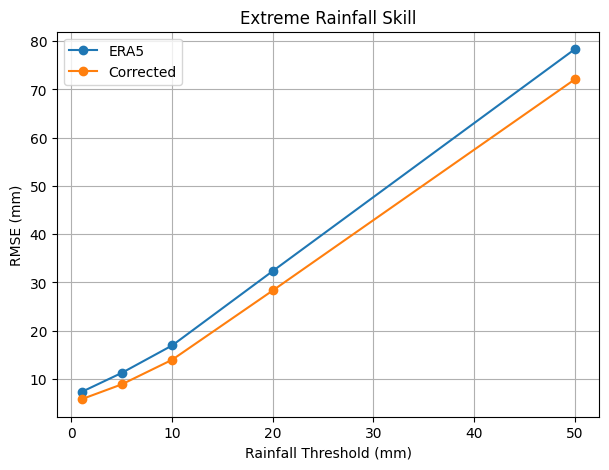

In [ ]:
thresholds = [1, 5, 10, 20, 50]

rmse_before_list = []
rmse_after_list = []

rf_era5_np_va = rf_era5_tensor_va.cpu().numpy()
rf_imdaa_np_va = rf_imdaa_tensor_va.cpu().numpy()
rf_corr_mm_np = rf_corr_mm.cpu().numpy()

for th in thresholds:

    mask = rf_imdaa_np_va > th

    if mask.sum() == 0:
        rmse_before_list.append(np.nan)
        rmse_after_list.append(np.nan)
        continue

    rmse_b = np.sqrt(
        np.mean(
            (rf_era5_np_va[mask] -
             rf_imdaa_np_va[mask]) ** 2
        )
    )

    rmse_a = np.sqrt(
        np.mean(
            (rf_corr_mm_np[mask] -
             rf_imdaa_np_va[mask]) ** 2
        )
    )

    rmse_before_list.append(rmse_b)
    rmse_after_list.append(rmse_a)

plt.figure(figsize=(7,5))
plt.plot(thresholds, rmse_before_list, marker="o", label="ERA5")
plt.plot(thresholds, rmse_after_list, marker="o", label="Corrected")
plt.xlabel("Rainfall Threshold (mm)")
plt.ylabel("RMSE (mm)")
plt.title("Extreme Rainfall Skill")
plt.legend()
plt.grid(True)
plt.show()

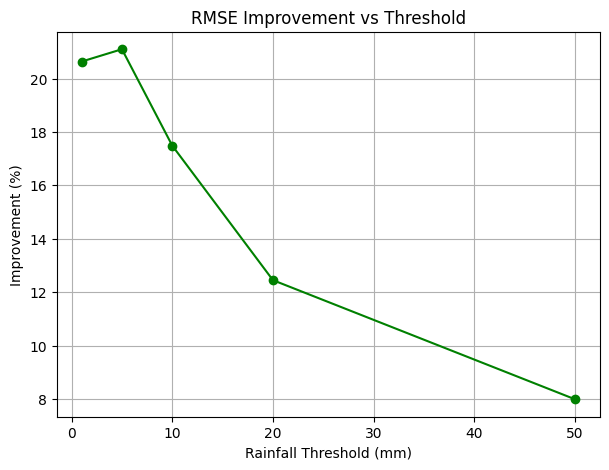

In [ ]:
improvement = [
    100 * (b - a) / b if not np.isnan(b) else np.nan
    for b, a in zip(rmse_before_list, rmse_after_list)
]

# Improvement plot
plt.figure(figsize=(7,5))
plt.plot(thresholds, improvement, marker="o", color="green")
plt.xlabel("Rainfall Threshold (mm)")
plt.ylabel("Improvement (%)")
plt.title("RMSE Improvement vs Threshold")
plt.grid(True)
plt.show()

In [ ]:
era5_np = rf_era5_tensor_va.cpu().numpy()
imdaa_np = rf_imdaa_tensor_va.cpu().numpy()
corr_np = rf_corr_mm.cpu().numpy()

# Temporal mean rainfall
mean_era5 = era5_np.mean(axis=0)
mean_imdaa = imdaa_np.mean(axis=0)
mean_corr = corr_np.mean(axis=0)

# Mean bias maps
bias_before_map = (era5_np - imdaa_np).mean(axis=0)
bias_after_map  = (corr_np - imdaa_np).mean(axis=0)

# RMSE maps
rmse_before_map = np.sqrt(((era5_np - imdaa_np) ** 2).mean(axis=0))
rmse_after_map  = np.sqrt(((corr_np - imdaa_np) ** 2).mean(axis=0))

# Improvement map
improvement_map = rmse_before_map - rmse_after_map

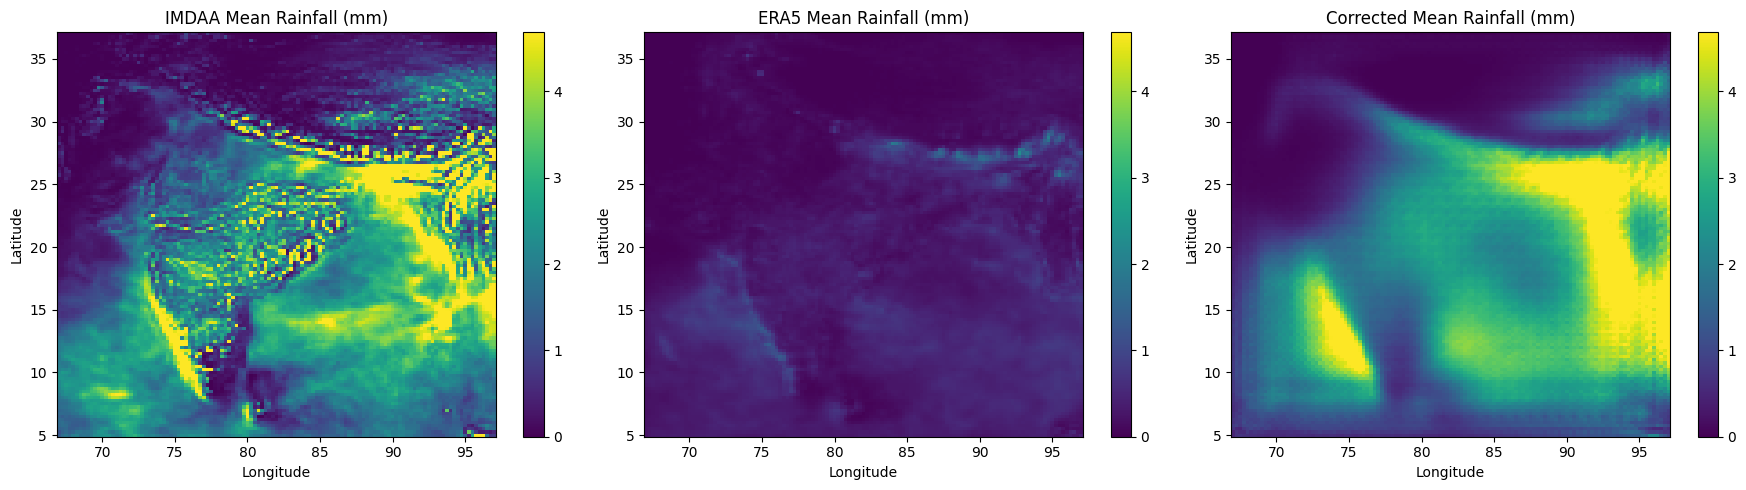

In [ ]:
# Mean Rainfall Comparison
vmax_rain = np.percentile(mean_imdaa, 95)
vmin_rain = 0

plt.figure(figsize=(18,5))

for i, (data, title) in enumerate([
    (mean_imdaa, "IMDAA Mean Rainfall (mm)"),
    (mean_era5,  "ERA5 Mean Rainfall (mm)"),
    (mean_corr,  "Corrected Mean Rainfall (mm)")
]):
    plt.subplot(1,3,i+1)
    plt.pcolormesh(lon, lat, data, shading="auto",
                   vmin=0, vmax=vmax_rain)
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar()

plt.tight_layout()
plt.show()

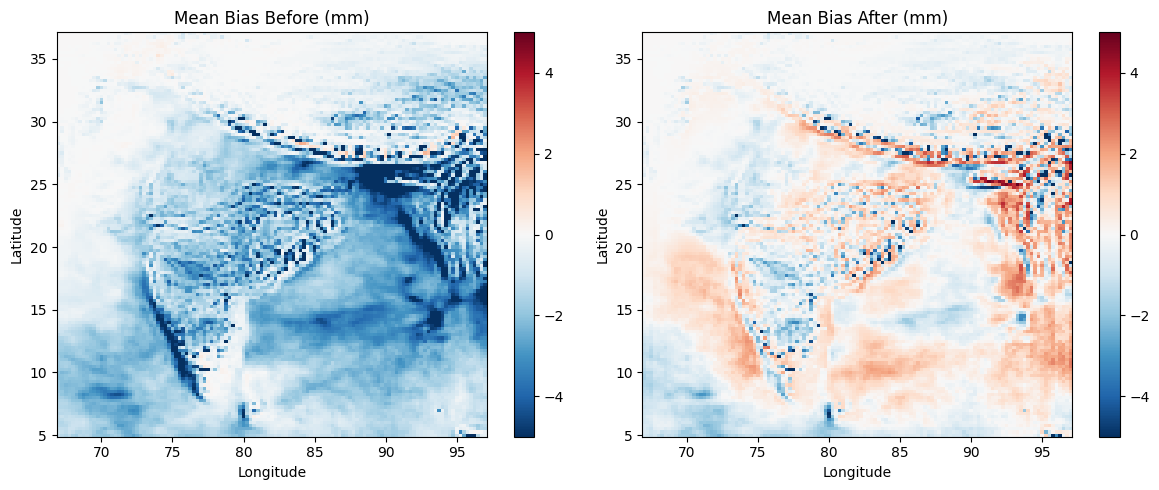

In [ ]:
# Mean Bias Comparison
vmax_bias = 5

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.pcolormesh(lon, lat, bias_before_map,
               shading="auto",
               cmap="RdBu_r",
               vmin=-vmax_bias, vmax=vmax_bias)
plt.title("Mean Bias Before (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()

plt.subplot(1,2,2)
plt.pcolormesh(lon, lat, bias_after_map,
               shading="auto",
               cmap="RdBu_r",
               vmin=-vmax_bias, vmax=vmax_bias)
plt.title("Mean Bias After (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()

plt.tight_layout()
plt.show()

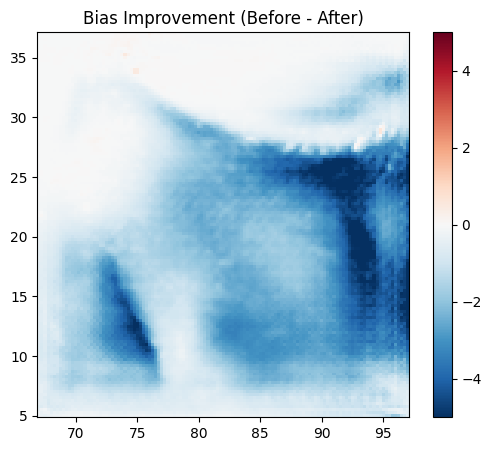

In [ ]:
bias_improve = bias_before_map - bias_after_map

plt.figure(figsize=(6,5))
plt.pcolormesh(lon, lat, bias_improve,
               shading="auto",
               cmap="RdBu_r",
               vmin=-vmax_bias,
               vmax=vmax_bias)
plt.title("Bias Improvement (Before - After)")
plt.colorbar()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


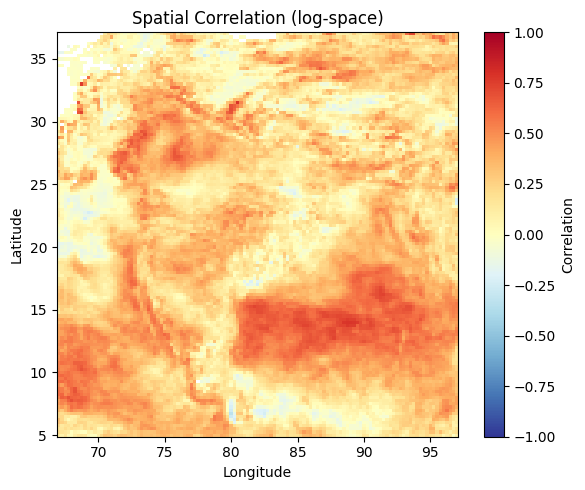

In [ ]:
# Spatial Correlation Map
corr_map = np.zeros_like(mean_imdaa)

for i in range(mean_imdaa.shape[0]):
    for j in range(mean_imdaa.shape[1]):

        obs = imdaa_np[:, i, j]
        pred = corr_np[:, i, j]

        valid = np.isfinite(obs) & np.isfinite(pred)

        obs = obs[valid]
        pred = pred[valid]

        if len(obs) > 20:
            corr_map[i, j] = np.corrcoef(
                np.log1p(pred),
                np.log1p(obs)
            )[0,1]
        else:
            corr_map[i, j] = np.nan

plt.figure(figsize=(6,5))
plt.pcolormesh(lon, lat, corr_map,
               shading="auto",
               cmap="RdYlBu_r",
               vmin=-1,
               vmax=1)

plt.title("Spatial Correlation (log-space)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

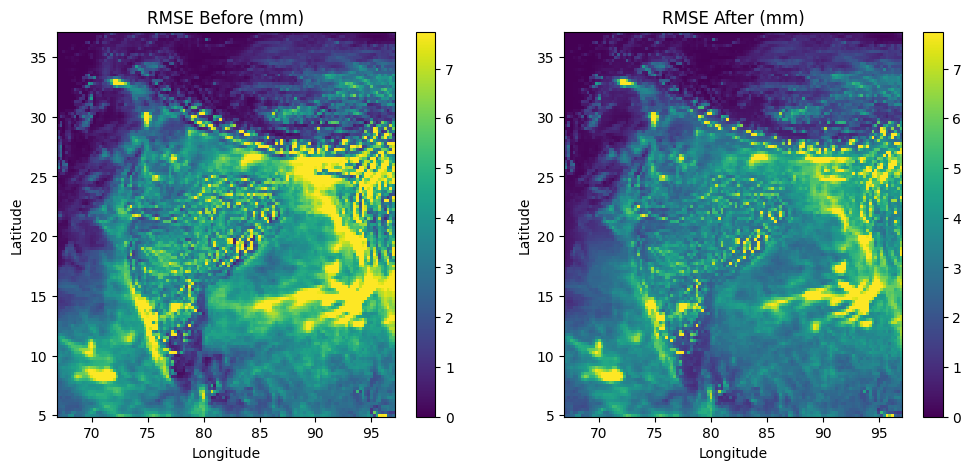

In [ ]:
# RMSE Maps
vmax_rmse = np.percentile(rmse_before_map, 95)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.pcolormesh(lon, lat, rmse_before_map,
               shading="auto",
               vmin=0, vmax=vmax_rmse)
plt.title("RMSE Before (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()

plt.subplot(1,2,2)
plt.pcolormesh(lon, lat, rmse_after_map,
               shading="auto",
               vmin=0, vmax=vmax_rmse)
plt.title("RMSE After (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()

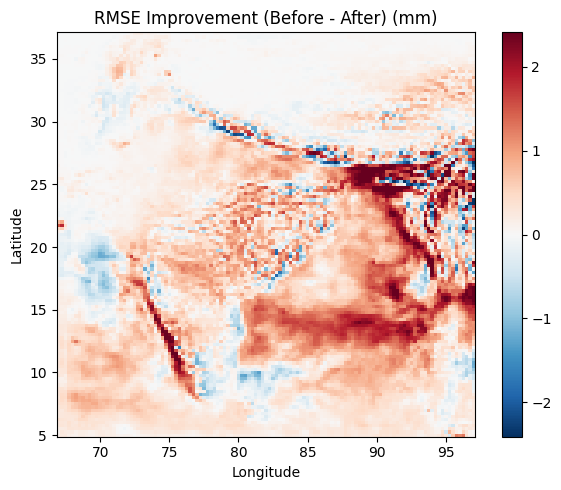

In [ ]:
# RMSE Improvement Map
vmax_improve = np.percentile(np.abs(improvement_map), 99)

plt.figure(figsize=(6,5))
plt.pcolormesh(lon, lat, improvement_map,
               shading="auto",
               cmap="RdBu_r",
               vmin=-vmax_improve,
               vmax=vmax_improve)
plt.title("RMSE Improvement (Before - After) (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/mtp2/bias_model_0.505DC.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "X_mean": X_mean,
    "X_std": X_std,
    "rain_threshold": 0.55,
}, save_path)

print("Model saved at:", save_path)

Model saved at: /content/drive/MyDrive/mtp2/bias_model_0.505DC.pth


In [ ]:
era5_np  = rf_era5_tensor_va.cpu().numpy()
imdaa_np = rf_imdaa_tensor_va.cpu().numpy()
corr_np  = rf_corr_mm.cpu().numpy()

rain_prob_np = rain_prob_va.squeeze(1).cpu().numpy()

np.savez(
    "/content/drive/MyDrive/mtp2/final_predictions505.npz",
    era5=era5_np,
    imdaa=imdaa_np,
    corrected=corr_np,
    rain_prob=rain_prob_np
)

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": opt.state_dict(),
}, "full_checkpoint505.pth")